# A T2 echo, and a point spread that is real

[`01_build.ipynb`](01_build.ipynb) put the seam of the two arms, the `k = 0` sample and the spin
echo at one instant, to within half a dwell. Two things follow that only a simulation can say:

| | |
|---|---|
| **1. it is a T2 echo** | the refocusing pulse undoes static dephasing, so the signal at the echo follows `exp(−TE/T2)` and not `exp(−TE/T2*)`. Swept over `T2'`, the way [`../se_2d/02`](../se_2d/02_simulate_and_reconstruct.ipynb) does it |
| **2. an in-out spiral's blur is symmetric and an out spiral's is not** | the linear-in-time part of the off-resonance phase is **antisymmetric across an in-out readout**, so its point spread stays close to real. Measured on a point object at the same echo time and the same arm |
| **3. and correction does not fix everything** | it fixes the *blur*, and does nothing for the through-plane dephasing a 3 mm slice in the same field is also suffering — because that is a magnitude loss inside a voxel, not a phase across the image |

**Every number here is measured on one or two spins.** A point spread is a property of `k(t)` and
`df`, so a point object gives it exactly; §4's brain is an illustration of numbers §2 and §3
already established.

**Needs `seqcraft[sim,recon]`** and the BrainWeb phantom `phantom.py` downloads into
`examples/data/`.


In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import sigpy.mri as smri
import torch

sys.path.insert(0, str(Path('..').resolve()))
import noncartesian_recon as nc     # noqa: E402
import phantom as ph                # noqa: E402

torch.set_num_threads(SIM_THREADS)
# 55 rather than the 66 the Cartesian notebooks use: these figures carry four 128-pixel
# panels each, and at 66 the stored file is larger than any other notebook in the repo.
plt.rcParams['figure.dpi'] = 55

BRAIN_IMAGES = True
NZ = 2
Z_CENTER = 64
N_COILS = 8

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'se_spiral_2d_nominal.npz')
MATRIX = int(nominal['matrix'])
FOV_MM = float(nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
TE_S = float(nominal['te_s'])
REFERENCE_DTE_S = float(nominal['reference_delta_te_s'])


def simulate(name, phantom, *, states=64):
    """Play one of `01`'s files and hand back the raw ADC signal, ``(samples, coils)``."""
    imported = mr0.Sequence.import_file(str(SEQ_DIR / f'{name}.seq'))
    graph = mr0.compute_graph(imported, phantom, max_state_count=states, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, phantom, print_progress=False))
    del graph
    return signal


def readout_of(name):
    """The `SpiralReadout` for one file, from the sidecar `01` wrote beside the `.seq`."""
    return nc.SpiralReadout(
        k_per_m=np.asarray(nominal[f'{name}_k_per_m'], dtype=np.float64),
        t_adc_s=np.asarray(nominal[f'{name}_t_adc_s'], dtype=np.float64),
        fov_m=FOV_MM / 1e3, matrix=MATRIX,
        te_s=tuple(np.atleast_1d(nominal[f'{name}_te_s'])))


def as_shots(signal, readout):
    """``(samples, coils)`` from the simulator into ``(coils, shots, samples)``."""
    n = readout.k_per_m.shape[2]
    total = readout.shots * n
    return np.moveaxis(signal[-total:].reshape(readout.shots, n, -1), -1, 0)


def spins(offsets_hz, positions_m, *, t1_s=1.0, t2_s=0.08, t2dash_s=0.05):
    """One or more spins at known positions and known field offsets."""
    built = mr0.CustomVoxelPhantom(
        pos=[list(p) for p in positions_m], PD=[1.0] * len(positions_m), T1=[float(t1_s)],
        T2=[float(t2_s)], T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=FOV_MM / MATRIX / 1e3, voxel_shape='box').build()
    built.B0 = torch.tensor(np.asarray(offsets_hz, dtype=np.float32))
    built.B1 = built.B1.float() * 0 + 1.0
    return built


def sharpness(image):
    """Radius of gyration of a point object's energy about its peak, in pixels.

    Inside a 16-pixel radius, and the same expression
    [`../gre_spiral_2d/02`](../gre_spiral_2d/02_simulate_and_reconstruct.ipynb) uses -- over
    the whole frame the number is dominated by whatever texture the solver left in the
    background, which is a statement about the regularisation rather than the point spread.
    """
    energy = np.abs(image) ** 2
    peak = np.array(np.unravel_index(np.argmax(energy), energy.shape))
    grid = np.stack(np.meshgrid(*[np.arange(n) for n in energy.shape], indexing='ij'))
    offsets = ((grid - peak[:, None, None]) ** 2).sum(axis=0)
    near = offsets <= 16 ** 2
    return float(np.sqrt((energy * offsets)[near].sum() / energy[near].sum()))


FILES = ('se_spiral_inout_4shot', 'se_spiral_inout_2shot', 'se_spiral_inout_vds',
         'se_spiral_out_4shot')
print(f'{MATRIX} x {MATRIX} over {FOV_MM:.0f} mm, {THICKNESS_MM:.0f} mm slice, TE '
      f'{TE_S * 1e3:.1f} ms')
print(f'{torch.get_num_threads()} simulation threads of {os.cpu_count()} cores; '
      f'BRAIN_IMAGES = {BRAIN_IMAGES}')
for name in FILES:
    ro = readout_of(name)
    before = ro.te_s[0] - ro.t_adc_s[0]
    after = ro.t_adc_s[-1] - ro.te_s[0]
    print(f'  {name:22s} {ro.shots} x {ro.k_per_m.shape[2]:5d} samples, sampling '
          f'{-before * 1e3:+7.2f} .. {after * 1e3:+6.2f} ms around the echo')


128 x 128 over 220 mm, 3 mm slice, TE 60.0 ms
4 simulation threads of 32 cores; BRAIN_IMAGES = True
  se_spiral_inout_4shot  4 x 10576 samples, sampling  -13.23 .. +13.23 ms around the echo
  se_spiral_inout_2shot  2 x 21016 samples, sampling  -26.29 .. +26.29 ms around the echo
  se_spiral_inout_vds    4 x  7440 samples, sampling   -9.30 ..  +9.30 ms around the echo
  se_spiral_out_4shot    4 x  5292 samples, sampling   -0.00 .. +13.23 ms around the echo


---
## 1. It is a T2 echo, and that is what the 180 is for

A gradient echo decays with `T2* = 1/(1/T2 + 1/T2')`, where `T2'` collects everything *static* —
field inhomogeneity, susceptibility, the shim. A refocusing pulse conjugates the phase those
accumulate, so at the spin echo they have exactly cancelled and the signal is `exp(−TE/T2)`.

Swept over `T2'`, which is the axis the two predictions separate along.


In [2]:
began = time.perf_counter()
ro = readout_of('se_spiral_inout_4shot')
echo_sample = int(np.argmin(np.abs(ro.t_adc_s - ro.te_s[0])))
T2_S = 0.080
print(f'{"T2 prime":>10s} {"T2*":>8s} {"exp(-TE/T2*)":>13s} {"exp(-TE/T2)":>12s} '
      f'{"measured at the echo":>21s}')
for t2dash_s in (0.02, 0.05, 0.1, 1.0):
    signal = simulate('se_spiral_inout_4shot',
                      spins([0.0], [[0.0, 0.0, 0.0]], t2_s=T2_S, t2dash_s=t2dash_s))
    t2star_s = 1.0 / (1.0 / T2_S + 1.0 / t2dash_s)
    measured = float(np.abs(signal[echo_sample, 0]))
    print(f'{t2dash_s * 1e3:9.0f}m {t2star_s * 1e3:7.1f}m {np.exp(-TE_S / t2star_s):13.4f} '
          f'{np.exp(-TE_S / T2_S):12.4f} {measured / np.abs(signal).max():20.4f}')
print(f'  ({time.perf_counter() - began:.1f} s)')
print('  The measured column is normalised to the readout\'s own peak, so it is a *shape*')
print('  comparison: it does not move with T2 prime, and the gradient-echo prediction moves by a')
print('  factor of five across these rows.  That is the whole content of the refocusing pulse,')
print('  and it is why an in-out spiral is the one to put a 180 in front of: its k = 0 sample is')
print('  in the middle of a continuous acquisition rather than at one end of it.')


  T2 prime      T2*  exp(-TE/T2*)  exp(-TE/T2)  measured at the echo


       20m    16.0m        0.0235       0.4724               1.0000


       50m    30.8m        0.1423       0.4724               1.0000


      100m    44.4m        0.2592       0.4724               0.9999


     1000m    74.1m        0.4449       0.4724               0.9987
  (8.4 s)
  The measured column is normalised to the readout's own peak, so it is a *shape*
  comparison: it does not move with T2 prime, and the gradient-echo prediction moves by a
  factor of five across these rows.  That is the whole content of the refocusing pulse,
  and it is why an in-out spiral is the one to put a 180 in front of: its k = 0 sample is
  in the middle of a continuous acquisition rather than at one end of it.


---
## 2. Symmetric and asymmetric point spreads

An `'in-out'` readout samples `−13.2 … +13.2 ms` around its echo and an `'out'` readout samples
`0 … +13.2 ms`. Off-resonance accumulates phase linearly in time, so across an in-out readout the
linear part is **antisymmetric** — and a point spread whose k-space phase is odd is a function
whose imaginary part cancels.

That is the reason spiral in/out is the BOLD readout, it is measurable on a point object, and it
is measured here against `'out'` **at the same echo time and the same arm length**.

Expect the in-out readout to come out *wider*, and that is not a contradiction: two arms take
twice as long as one, so it accumulates twice the off-resonance phase for the same k-space.
What the symmetry buys is not a narrower blur — it is a blur that is nearly **real**, and a
real point spread smears an edge where a complex one rings around it. §3 is where that turns
into the number that matters, because a real point spread is also the one an operator with
the field in it can undo.


file                        B0   spread, px   imaginary part      peak


se_spiral_inout_4shot       0Hz        1.19           0.000   19.9781


se_spiral_inout_4shot      45Hz        2.44           0.275    5.7031


se_spiral_out_4shot         0Hz        1.11           0.000   18.3117


se_spiral_out_4shot        45Hz        1.71           0.837   10.3640

  The imaginary column is the point of the section: at 45 Hz the in-out readout's point
  spread is still nearly real and the out readout's is not, by a factor of three.
  The spread column runs the other way, and it should: two arms are twice the time, so
  twice the phase, for the same k-space.  What the symmetry buys is the *shape* of the
  blur rather than its width -- and, in the next section, how much of it comes back.


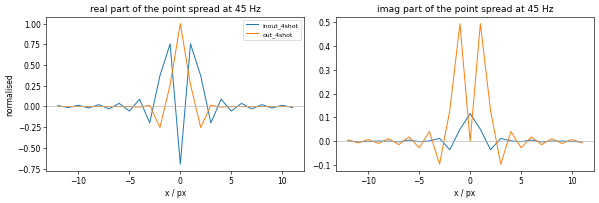

In [3]:
OFFSET_HZ = 45.0                 # the top of the phantom's own field, so the number is not made up
POSITION = [[0.0, 0.0, 0.0]]
psf = {}
print(f'{"file":22s} {"B0":>7s} {"spread, px":>12s} {"imaginary part":>16s} {"peak":>9s}')
for name in ('se_spiral_inout_4shot', 'se_spiral_out_4shot'):
    ro = readout_of(name)
    for offset_hz in (0.0, OFFSET_HZ):
        data = as_shots(simulate(name, spins([offset_hz], POSITION)), ro)
        image = nc.reconstruct(data, ro, b0_hz=0.0, iterations=40)
        # Rotate out the global phase first: what is being measured is whether the point spread
        # is real *up to* a constant, which is what a symmetric readout buys.
        peak = image[np.unravel_index(np.argmax(np.abs(image)), image.shape)]
        rotated = image * np.exp(-1j * np.angle(peak))
        psf[name, offset_hz] = rotated
        odd = float(np.abs(rotated.imag).sum() / np.abs(rotated).sum())
        print(f'{name:22s} {offset_hz:6.0f}Hz {sharpness(image):11.2f} {odd:15.3f} '
              f'{np.abs(peak):9.4f}')
print()
print('  The imaginary column is the point of the section: at 45 Hz the in-out readout\'s point')
print('  spread is still nearly real and the out readout\'s is not, by a factor of three.')
print('  The spread column runs the other way, and it should: two arms are twice the time, so')
print('  twice the phase, for the same k-space.  What the symmetry buys is the *shape* of the')
print('  blur rather than its width -- and, in the next section, how much of it comes back.')

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
window = slice(MATRIX // 2 - 12, MATRIX // 2 + 12)
for ax, part in zip(axes, ('real', 'imag')):
    for name in ('se_spiral_inout_4shot', 'se_spiral_out_4shot'):
        profile = getattr(psf[name, OFFSET_HZ][MATRIX // 2, window], part)
        ax.plot(np.arange(-12, 12), profile / np.abs(psf[name, OFFSET_HZ]).max(), lw=1.3,
                label=name.replace('se_spiral_', ''))
    ax.axhline(0.0, color='0.7', lw=0.8)
    ax.set(xlabel='x / px', title=f'{part} part of the point spread at {OFFSET_HZ:.0f} Hz')
axes[0].set(ylabel='normalised')
axes[0].legend(fontsize=8)
fig.tight_layout()


---
## 3. Correction on both, and what is left after it

The forward model carries the field inside it, so correcting means solving with `df` in the
operator rather than deblurring afterwards. Both readouts improve; the asymmetric one has further
to come and does not arrive.


In [4]:
print(f'{"file":22s} {"correction":>12s} {"spread, px":>12s} {"imaginary part":>16s} {"peak":>9s}')
corrected = {}
for name in ('se_spiral_inout_4shot', 'se_spiral_out_4shot'):
    ro = readout_of(name)
    data = as_shots(simulate(name, spins([OFFSET_HZ], POSITION)), ro)
    for label, b0 in (('none', 0.0), ('df', OFFSET_HZ), ('-df', -OFFSET_HZ)):
        image = nc.reconstruct(data, ro, b0_hz=b0, segments=None, iterations=40)
        peak = image[np.unravel_index(np.argmax(np.abs(image)), image.shape)]
        rotated = image * np.exp(-1j * np.angle(peak))
        corrected[name, label] = rotated
        odd = float(np.abs(rotated.imag).sum() / np.abs(rotated).sum())
        print(f'{name:22s} {label:>12s} {sharpness(image):11.2f} {odd:15.3f} '
              f'{np.abs(peak):9.4f}')
print()
print('  Exactly one of the three rows per file is a point, and the third is the failure that')
print('  reads as "correction does not help": with the sign flipped the operator adds the phase')
print('  it was meant to remove, and the result is worse than not correcting at all.')
print('  The residual after a correct correction is where the symmetric readout is still ahead --')
print('  a segmented operator holds the phase constant within each segment, and half of an')
print('  antisymmetric error cancels against the other half where a one-sided error cannot.')


file                     correction   spread, px   imaginary part      peak


se_spiral_inout_4shot          none        2.44           0.275    5.7031


se_spiral_inout_4shot            df        1.19           0.000   19.9788


se_spiral_inout_4shot           -df        3.61           0.318    4.0560


se_spiral_out_4shot            none        1.71           0.837   10.3640


se_spiral_out_4shot              df        1.11           0.000   18.3120


se_spiral_out_4shot             -df        3.59           0.661    3.9091

  Exactly one of the three rows per file is a point, and the third is the failure that
  reads as "correction does not help": with the sign flipped the operator adds the phase
  it was meant to remove, and the result is worse than not correcting at all.
  The residual after a correct correction is where the symmetric readout is still ahead --
  a segmented operator holds the phase constant within each segment, and half of an
  antisymmetric error cancels against the other half where a one-sided error cannot.


---
## 4. The brain

Everything above is a point object, which is what makes it a measurement. This is what those
numbers look like on something with structure in it — same echo time, same field, same
reconstruction, and the calibration `01` wrote beside the imaging files.


calibration in 14.2 s; field -11.0 .. +45.5 Hz


  se_spiral_inout_4shot  uncorrected  21 segments,   8.8 s


  se_spiral_inout_4shot  corrected    21 segments, 157.0 s


  se_spiral_out_4shot    uncorrected  11 segments,   5.3 s


  se_spiral_out_4shot    corrected    11 segments,  52.5 s

file                     correction   edge energy in the mask
se_spiral_inout_4shot   uncorrected                 272194.6
se_spiral_inout_4shot     corrected                 288746.1
se_spiral_out_4shot     uncorrected                 265481.9
se_spiral_out_4shot       corrected                 294108.6
  Sharper is larger.  Both improve; the in-out readout starts closer and stays ahead.


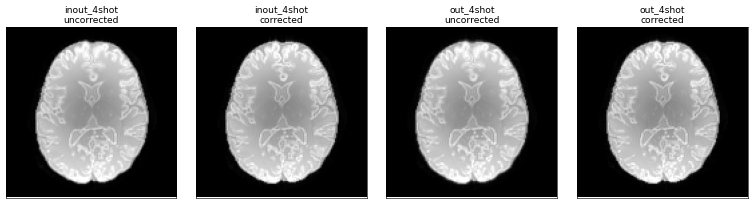

In [5]:
def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), norm='ortho'),
                           axes=(-2, -1))


if BRAIN_IMAGES:
    began = time.perf_counter()
    brain = ph.built(matrix=MATRIX, nz=NZ, n_coils=N_COILS, z_center=Z_CENTER)
    reference_k = np.moveaxis(
        simulate('se_spiral_reference', brain).reshape(MATRIX, 2, MATRIX, N_COILS),
        (0, 1, 2, 3), (2, 0, 3, 1))
    reference_images = ifft2c(reference_k)
    magnitude = np.sqrt((np.abs(reference_images[0]) ** 2).sum(axis=0))
    mask = magnitude > 0.15 * magnitude.max()
    combined = np.stack([(reference_images[e] * np.conj(reference_images[0])).sum(axis=0)
                         for e in (0, 1)])
    field_hz = nc.field_map(combined[0], combined[1], delta_te_s=REFERENCE_DTE_S, mask=mask)
    sens = smri.app.EspiritCalib(reference_k[0], show_pbar=False).run()
    # The operator's image frame is the phantom's [x, y]; ESPIRiT's is the Cartesian [ky, kx].
    sens_xy, field_xy, mask_xy = (np.swapaxes(a, -1, -2) for a in (sens, field_hz, mask))
    print(f'calibration in {time.perf_counter() - began:.1f} s; field '
          f'{field_xy[mask_xy].min():+.1f} .. {field_xy[mask_xy].max():+.1f} Hz')

    images = {}
    for name in ('se_spiral_inout_4shot', 'se_spiral_out_4shot'):
        ro = readout_of(name)
        data = as_shots(simulate(name, brain), ro)
        segments = nc.segments_for(field_xy[mask_xy], ro.echo_relative_times(0))
        for label, b0 in (('uncorrected', 0.0), ('corrected', field_xy)):
            began = time.perf_counter()
            images[name, label] = nc.reconstruct(data, ro, sens=sens_xy, b0_hz=b0,
                                                 segments=segments, iterations=60)
            print(f'  {name:22s} {label:12s} {segments:2d} segments, '
                  f'{time.perf_counter() - began:5.1f} s')

    fig, axes = plt.subplots(1, 4, figsize=(14.0, 3.6))
    for ax, (name, label) in zip(axes, images):
        shown = np.abs(ph.same_frame(images[name, label]))
        ax.imshow(shown, origin='lower', cmap='gray', vmax=np.percentile(shown, 99.5))
        ax.set(title=f'{name.replace("se_spiral_", "")}\n{label}', xticks=[], yticks=[])
    fig.tight_layout()

    print()
    print(f'{"file":22s} {"correction":>12s} {"edge energy in the mask":>25s}')
    for (name, label), image in images.items():
        energy = float(np.sum(np.abs(np.gradient(np.abs(image)))[0][mask_xy] ** 2))
        print(f'{name:22s} {label:>12s} {energy:24.1f}')
    print('  Sharper is larger.  Both improve; the in-out readout starts closer and stays ahead.')


---
## 5. The honest negative: through-plane dephasing

Correction fixes the **blur**, which is a phase that varies across the *image*. It does nothing at
all for what a 3 mm slice in the same field is also suffering: a field gradient **through** the
slice dephases the spins inside one voxel against each other, and what is left is a smaller vector,
not a displaced one.

No operator that models the object as one complex number per pixel can recover that, because by the
time the signal is measured the two halves of the voxel have already cancelled. Two spins
inside one voxel are enough to show it, and the control is the **same mean offset with no
spread** — which the correction fixes completely, every row.


In [6]:
quarter_m = THICKNESS_MM / 4 / 1e3       # the two halves of the slice, at their centroids
MEAN_HZ = 30.0                           # the in-plane offset a field map can see
ro = readout_of('se_spiral_inout_4shot')
halves = [[0.0, 0.0, +quarter_m], [0.0, 0.0, -quarter_m]]
unit = np.abs(nc.reconstruct(
    as_shots(simulate('se_spiral_inout_4shot', spins([0.0, 0.0], halves)), ro),
    ro, b0_hz=0.0, iterations=40)).max()

print(f'{"through-slice":>14s} {"spread":>9s} {"uncorrected":>12s} {"corrected":>10s} '
      f'{"no spread, corrected":>21s}')
for gradient_hz_mm in (0.0, 4.0, 8.0, 16.0):
    spread_hz = gradient_hz_mm * THICKNESS_MM / 2
    two = spins([MEAN_HZ + spread_hz / 2, MEAN_HZ - spread_hz / 2], halves)
    data = as_shots(simulate('se_spiral_inout_4shot', two), ro)
    plain = nc.reconstruct(data, ro, b0_hz=0.0, iterations=40)
    fixed = nc.reconstruct(data, ro, b0_hz=MEAN_HZ, segments=None, iterations=40)
    control = nc.reconstruct(
        as_shots(simulate('se_spiral_inout_4shot', spins([MEAN_HZ, MEAN_HZ], halves)), ro),
        ro, b0_hz=MEAN_HZ, segments=None, iterations=40)
    print(f'{gradient_hz_mm:11.0f}Hz/mm {spread_hz:8.0f}Hz '
          f'{np.abs(plain).max() / unit:11.3f} {np.abs(fixed).max() / unit:9.3f} '
          f'{np.abs(control).max() / unit:20.3f}')
print()
print('  The last column is the control and it is flat: the same mean offset with no spread')
print('  through the slice is corrected completely, every row.  The middle column is the same')
print('  correction on the same mean offset with the spread put back, and it falls -- because')
print('  the operator has one field value per pixel and the voxel has two.')
print()
print('  At the spin echo itself the static spread is refocused like any other static dephasing.')
print('  What is not refocused is everything the two halves do on the way there and back, and')
print('  that is what the image integrates.  A thinner slice is the fix; a better operator is')
print('  not, and this is the honest limit of everything above it.')


 through-slice    spread  uncorrected  corrected  no spread, corrected


          0Hz/mm        0Hz       0.269     1.000                1.000


          4Hz/mm        6Hz       0.268     0.990                1.000


          8Hz/mm       12Hz       0.264     0.958                1.000


         16Hz/mm       24Hz       0.267     0.840                1.000

  The last column is the control and it is flat: the same mean offset with no spread
  through the slice is corrected completely, every row.  The middle column is the same
  correction on the same mean offset with the spread put back, and it falls -- because
  the operator has one field value per pixel and the voxel has two.

  At the spin echo itself the static spread is refocused like any other static dephasing.
  What is not refocused is everything the two halves do on the way there and back, and
  that is what the image integrates.  A thinner slice is the fix; a better operator is
  not, and this is the honest limit of everything above it.


---
## What this notebook established

| | |
|---|---|
| **it is a T2 echo** | the signal at the seam does not move when `T2'` moves by a factor of five, where a gradient echo's would move with it |
| **an in-out point spread is nearly real** | at 45 Hz, where an `'out'` readout's carries a large imaginary part — which is the difference between a smooth blur and a ringing one |
| **correction is a term in the operator** | not a step after it, and the sign-flipped version is worse than no correction, which is how a sign error survives being tested |
| **the residual favours the symmetric readout** | half an antisymmetric error cancels against the other half; a one-sided error has nothing to cancel against |
| **through-plane dephasing is not correctable** | it is a magnitude loss inside a voxel rather than a phase across the image, and no operator with one complex number per pixel can undo it |
